In [3]:
import numpy as np
from scipy.stats import genpareto
from statsmodels.distributions.empirical_distribution import ECDF

def fit_evttail_transform(series, threshold, xi, sigma):
    """
    Applies a hybrid Probability Integral Transform using:
    - GPD model for tail (x < threshold)
    - Empirical CDF for the center of the distribution (x >= threshold)

    Parameters:
    ----------
    series : pd.Series
        Log return time series for a single asset.
    threshold : float
        Tail threshold (x < threshold defines tail).
    xi : float
        GPD shape parameter ξ.
    sigma : float
        GPD scale parameter σ.

    Returns:
    -------
    u : pd.Series
        Series transformed to [0, 1] via hybrid PIT.
    """
    # Separate tail and center
    tail_mask = series < threshold
    tail_data = series[tail_mask]
    center_data = series[~tail_mask]

    # Empirical CDF on center region
    ecdf = ECDF(center_data)
    u_center = pd.Series(ecdf(center_data), index=center_data.index)

    # GPD CDF on tail region
    excess = threshold - tail_data
    u_tail = pd.Series(
        genpareto.cdf(excess, c=xi, scale=sigma),
        index=tail_data.index
    )

    # Join
    u = pd.concat([u_tail, u_center]).sort_index()
    return u

In [5]:
# Load EVT-fitted return data and parameters
returns = pd.read_parquet("../data/processed/returns.parquet")
gpd_params = pd.read_csv("../data/processed/gpd_summary.csv")

# Choose two marginals for copula modeling
assets = ["BTC-USD", "ETH-USD"]
u_data = {}

for asset in assets:
    series = returns[asset].dropna()
    row = gpd_params[gpd_params["Asset"] == asset].iloc[0]

    threshold = row["Threshold"]
    xi = row["Shape (ξ)"]
    sigma = row["Scale (σ)"]

    u_data[asset] = fit_evttail_transform(series, threshold, xi, sigma)

# Combine into 2D DataFrame (u-space)
uniform_df = pd.DataFrame(u_data).dropna()
uniform_df.head()

,BTC-USD,ETH-USD
Date,,
2017-11-10,0.465535,0.009004
2017-11-13,0.983680,0.763084
2017-11-14,0.648846,0.924592
2017-11-15,0.984243,0.312887
2017-11-17,0.172763,0.530670


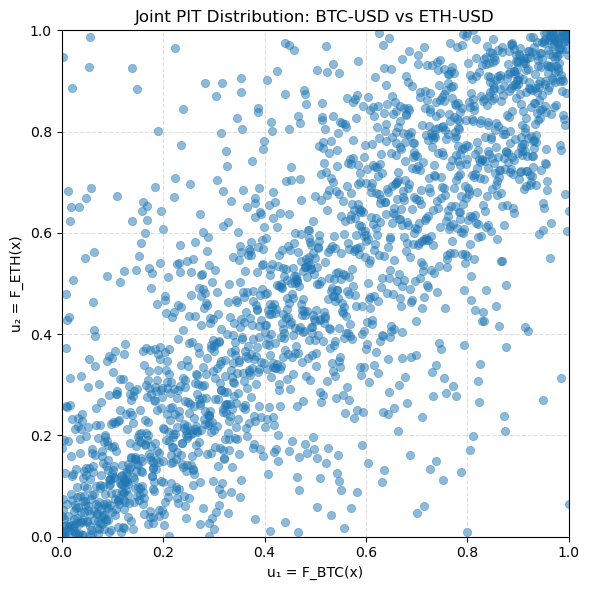

In [11]:
# --------------------------------------------
# 🔍 Visual Diagnostic: Joint PIT Distribution
# --------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=uniform_df,
    x="BTC-USD", y="ETH-USD",
    alpha=0.5, edgecolor=None
)

plt.title("Joint PIT Distribution: BTC-USD vs ETH-USD")
plt.xlabel("u₁ = F_BTC(x)")
plt.ylabel("u₂ = F_ETH(x)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [23]:
# Safely apply norm.ppf by clipping uniform values away from 0 and 1
u_clean = uniform_df.dropna().clip(lower=1e-6, upper=1 - 1e-6)
z_data = norm.ppf(u_clean)

# Recompute correlation on clean z-scores
emp_corr = np.corrcoef(z_data.T)
rho = emp_corr[0, 1]

In [25]:
from scipy.stats import multivariate_normal

# Define the multivariate normal distribution using the estimated correlation
copula_mvn = multivariate_normal(mean=[0, 0], cov=[[1, rho], [rho, 1]])

# Compute log-likelihood of copula (excluding marginal contribution)
log_likelihood_gauss = np.sum(copula_mvn.logpdf(z_data)) - np.sum(norm.logpdf(z_data))

# Output results
print("📈 Fitted Gaussian Copula:")
print(f"Estimated ρ (correlation): {rho:.4f}")
print(f"Log-Likelihood:            {log_likelihood_gauss:.2f}")

📈 Fitted Gaussian Copula:
Estimated ρ (correlation): 0.7511
Log-Likelihood:            777.02


In [29]:
from scipy.stats import t as student_t
from scipy.optimize import minimize

# ------------------------------------------------------
# Define bivariate Student-t copula negative log-likelihood
# ------------------------------------------------------
def student_t_copula_negloglik(params, u):
    rho, nu = params
    if not (-0.99 < rho < 0.99 and nu > 2):  # enforce valid bounds
        return np.inf

    u1, u2 = u[:, 0], u[:, 1]

    # Transform u to t-scores using inverse CDF
    t1 = student_t.ppf(u1, df=nu)
    t2 = student_t.ppf(u2, df=nu)

    # Compute Q matrix term
    q = (t1**2 - 2 * rho * t1 * t2 + t2**2) / (1 - rho**2)

    # Marginal log-density
    log_pdf1 = student_t.logpdf(t1, df=nu)
    log_pdf2 = student_t.logpdf(t2, df=nu)

    # Joint log-density
    log_det = -0.5 * np.log(1 - rho**2)
    log_kernel = - (nu + 2) / 2 * np.log(1 + q / (nu * (1 - rho**2)))
    log_joint = log_det + log_kernel

    # Copula log-density is joint - marginals
    log_copula = log_joint - log_pdf1 - log_pdf2

    return -np.sum(log_copula)

# ------------------------------------------------------
# Fit Student-t Copula via MLE
# ------------------------------------------------------
initial_params = [rho, 5.0]                  # start from Gaussian ρ, ν=5
bounds = [(-0.99, 0.99), (2.01, 50)]         # bounds on ρ and ν

result = minimize(student_t_copula_negloglik, initial_params, args=(u_clean,), bounds=bounds)

rho_t, nu_t = result.x
log_likelihood_t = -result.fun

# ------------------------------------------------------
# Output results
# ------------------------------------------------------
print("📘 Fitted Student-t Copula:")
print(f"Estimated ρ (correlation):     {rho_t:.4f}")
print(f"Estimated ν (degrees freedom): {nu_t:.2f}")
print(f"Log-Likelihood:                {log_likelihood_t:.2f}")

📘 Fitted Student-t Copula:
Estimated ρ (correlation):     0.7511
Estimated ν (degrees freedom): 5.00
Log-Likelihood:                2454.91


C:\Users\Asad\anaconda3\Lib\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [31]:
from scipy.optimize import minimize

# ------------------------------------------
# Define Clayton Copula Log-Likelihood
# ------------------------------------------
def clayton_log_likelihood(theta, u):
    if theta <= 0:
        return np.inf  # Clayton only valid for θ > 0

    u1, u2 = u[:, 0], u[:, 1]
    
    # Avoid division by 0 or log of 0 by clipping values
    u1 = np.clip(u1, 1e-10, 1 - 1e-10)
    u2 = np.clip(u2, 1e-10, 1 - 1e-10)

    # Copula density log-form (joint density)
    log_c = (
        np.log(theta + 1)
        + (-(theta + 1)) * (np.log(u1) + np.log(u2))
        - (2 + 1 / theta) * np.log(u1 ** (-theta) + u2 ** (-theta) - 1)
    )

    return -np.sum(log_c)  # negative log-likelihood

In [33]:
# ------------------------------------------
# Fit Clayton Copula via MLE
# ------------------------------------------

# Clean data already prepared: u_clean from previous step
init_theta = 1.0  # reasonable starting value
bounds = [(1e-4, 50)]  # θ must be > 0

result = minimize(
    clayton_log_likelihood,
    x0=[init_theta],
    args=(u_clean,),
    bounds=bounds
)

# Extract results
theta_clayton = result.x[0]
log_likelihood_clayton = -result.fun

# ------------------------------------------
# Output fitted results
# ------------------------------------------
print("📘 Fitted Clayton Copula:")
print(f"Estimated θ (dependency): {theta_clayton:.4f}")
print(f"Log-Likelihood:           {log_likelihood_clayton:.2f}")

📘 Fitted Clayton Copula:
Estimated θ (dependency): 1.6527
Log-Likelihood:           619.83


In [37]:
# --------------------------------------------------------------
# 📘 Gumbel Copula: Numerically Stable Log-Likelihood Function
# --------------------------------------------------------------
import numpy as np

def gumbel_log_likelihood(theta, u):
    """
    Compute the negative log-likelihood for the Gumbel copula.

    Parameters:
        theta (float): Gumbel dependency parameter (θ ≥ 1).
        u (ndarray): 2D array of uniform marginals (shape: [n_obs, 2]).

    Returns:
        float: Negative log-likelihood value.
    """
    if theta < 1:
        return np.inf  # Gumbel is only defined for θ ≥ 1

    u1, u2 = u[:, 0], u[:, 1]

    # 🔐 Stability fix: avoid log(0) by clipping
    ln_u1 = -np.log(np.clip(u1, 1e-10, 1))
    ln_u2 = -np.log(np.clip(u2, 1e-10, 1))

    # Compute Gumbel exponent
    w = (ln_u1 ** theta + ln_u2 ** theta) ** (1 / theta)

    # Log copula density
    log_c = (
        -w
        + (theta - 1) * (np.log(ln_u1) + np.log(ln_u2))
        + (theta + 1) * np.log(w)
        - (np.log(u1) + np.log(u2))
    )

    return -np.sum(log_c)

In [39]:
# --------------------------------------------------------------
# 📐 Fit Gumbel Copula via Maximum Likelihood Estimation (MLE)
# --------------------------------------------------------------

# Clean PIT data already prepared: u_clean from earlier

# ⬇️ Initial guess and bounds
init_theta = 2.0  # Must be >= 1 for Gumbel
bounds = [(1.0001, 50)]  # Gumbel defined only for θ ≥ 1

# 🔧 Optimize negative log-likelihood using scipy
result = minimize(
    gumbel_log_likelihood,
    x0=[init_theta],
    args=(u_clean,),
    bounds=bounds
)

# 📤 Extract results
theta_gumbel = result.x[0]
log_likelihood_gumbel = -result.fun

# ✅ Display results
print("📐 Fitted Gumbel Copula:")
print(f"Estimated θ (dependency):    {theta_gumbel:.4f}")
print(f"Log-Likelihood:              {log_likelihood_gumbel:.2f}")

📐 Fitted Gumbel Copula:
Estimated θ (dependency):    1.0001
Log-Likelihood:              759.09


In [41]:
# ----------------------------------------------
# 📊 Copula Model Comparison: LogL, AIC, BIC
# ----------------------------------------------

# Define model metadata
models = ["Gaussian", "Student-t", "Clayton", "Gumbel"]
log_likelihoods = [log_likelihood_gauss, log_likelihood_t, log_likelihood_clayton, log_likelihood_gumbel]
k_params = [1, 2, 1, 1]  # number of parameters per model
n_obs = len(u_clean)

# Compute AIC and BIC
aic = [-2 * ll + 2 * k for ll, k in zip(log_likelihoods, k_params)]
bic = [-2 * ll + np.log(n_obs) * k for ll, k in zip(log_likelihoods, k_params)]

# Store param values for display
param_1 = [rho, rho_t, theta_clayton, theta_gumbel]
param_2 = [None, nu_t, None, None]

# Create comparison DataFrame
copula_results = pd.DataFrame({
    "Model": models,
    "Log-Likelihood": log_likelihoods,
    "Param 1": param_1,
    "Param 2": param_2,
    "AIC": aic,
    "BIC": bic
})

# Sort by best (lowest AIC)
copula_results_sorted = copula_results.sort_values("AIC", ascending=True).reset_index(drop=True)
copula_results_sorted

,Model,Log-Likelihood,Param 1,Param 2,AIC,BIC
0,Student-t,2454.908807,0.751138,5.0,-4905.817613,-4894.749157
1,Gaussian,777.020116,0.751138,NaN,-1552.040233,-1546.506004
2,Gumbel,759.087441,1.000100,NaN,-1516.174883,-1510.640655
3,Clayton,619.825945,1.652739,NaN,-1237.651890,-1232.117662


C:\Users\Public\Documents\iSkysoft\CreatorTemp\ipykernel_14048\2652046664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


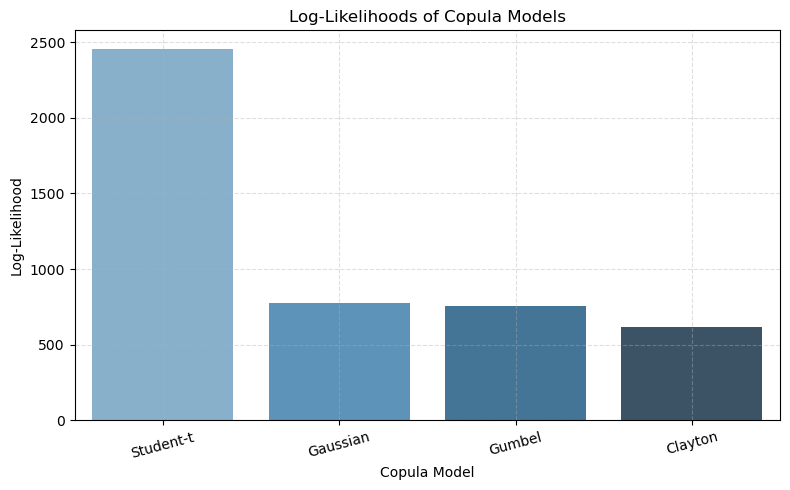

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=copula_results_sorted,
    x="Model",
    y="Log-Likelihood",
    palette="Blues_d"
)
plt.title("Log-Likelihoods of Copula Models")
plt.xlabel("Copula Model")
plt.ylabel("Log-Likelihood")
plt.xticks(rotation=15)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

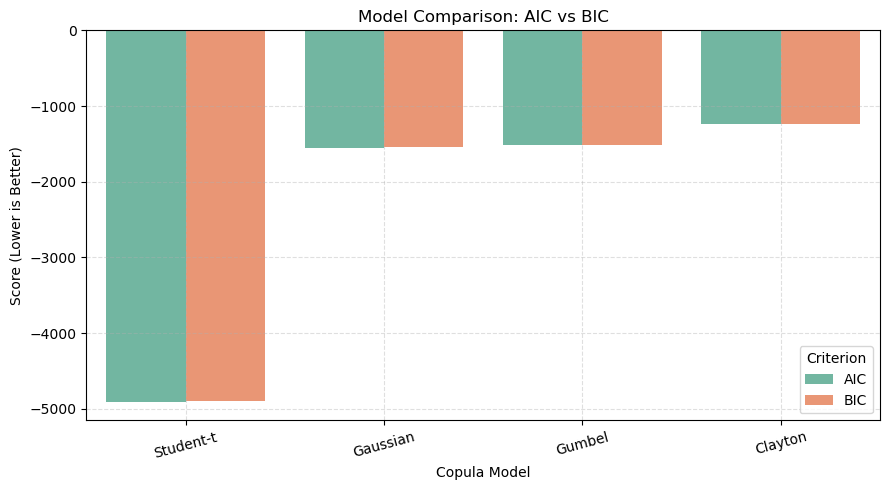

In [45]:
copula_results_melted = copula_results_sorted.melt(
    id_vars="Model",
    value_vars=["AIC", "BIC"],
    var_name="Criterion",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=copula_results_melted,
    x="Model",
    y="Score",
    hue="Criterion",
    palette="Set2"
)
plt.title("Model Comparison: AIC vs BIC")
plt.xlabel("Copula Model")
plt.ylabel("Score (Lower is Better)")
plt.xticks(rotation=15)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [47]:
# ---------------------------------------------------
# Compute Empirical Tail Dependence (λ_upper, λ_lower)
# ---------------------------------------------------

def empirical_tail_dependence(u_df, threshold=0.05):
    """
    Compute empirical tail dependence coefficients.
    λ_upper: Probability both PIT values > (1 - threshold)
    λ_lower: Probability both PIT values < threshold
    """
    u1 = u_df.iloc[:, 0]
    u2 = u_df.iloc[:, 1]
    n = len(u_df)

    # Upper tail dependence
    upper_joint = ((u1 > 1 - threshold) & (u2 > 1 - threshold)).sum()
    lambda_upper = upper_joint / (threshold * n)

    # Lower tail dependence
    lower_joint = ((u1 < threshold) & (u2 < threshold)).sum()
    lambda_lower = lower_joint / (threshold * n)

    return lambda_upper, lambda_lower

# Compute using uniform_df (PIT-transformed marginals)
lambda_upper, lambda_lower = empirical_tail_dependence(uniform_df, threshold=0.05)

# Display results
print(f"Empirical λ_upper (0.95+): {lambda_upper:.3f}")
print(f"Empirical λ_lower (<0.05): {lambda_lower:.3f}")

Empirical λ_upper (0.95+): 0.470
Empirical λ_lower (<0.05): 0.363


In [49]:
# -----------------------------------------------
# 📐 Compute Theoretical Tail Dependence (λ_upper, λ_lower)
# -----------------------------------------------

# Clayton Copula: Lower tail dependence only
lambda_lower_clayton = 2 ** (-1 / theta_clayton)
lambda_upper_clayton = 0  # Clayton has no upper tail dependence

# Gumbel Copula: Upper tail dependence only
lambda_upper_gumbel = 2 - 2 ** (1 / theta_gumbel)
lambda_lower_gumbel = 0  # Gumbel has no lower tail dependence

# 🖨️ Display results
print("Clayton Copula Tail Dependence:")
print(f"λ_lower (theoretical) = {lambda_lower_clayton:.3f}")
print(f"λ_upper (theoretical) = {lambda_upper_clayton:.3f}")

print("\nGumbel Copula Tail Dependence:")
print(f"λ_upper (theoretical) = {lambda_upper_gumbel:.3f}")
print(f"λ_lower (theoretical) = {lambda_lower_gumbel:.3f}")

Clayton Copula Tail Dependence:
λ_lower (theoretical) = 0.657
λ_upper (theoretical) = 0.000

Gumbel Copula Tail Dependence:
λ_upper (theoretical) = 0.000
λ_lower (theoretical) = 0.000


C:\Users\Public\Documents\iSkysoft\CreatorTemp\ipykernel_14048\3924673126.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


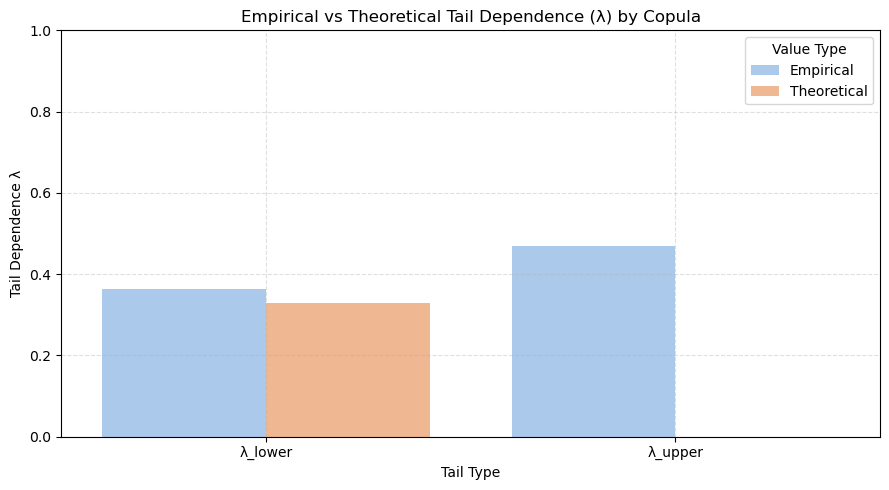

In [51]:
# ---------------------------------------------
# 📊 Visual Comparison: Empirical vs Theoretical λ_upper and λ_lower
# ---------------------------------------------

# Assemble all tail dependence results
tail_data = pd.DataFrame({
    "Model": ["Clayton", "Clayton", "Gumbel", "Gumbel"],
    "Tail": ["λ_lower", "λ_upper", "λ_lower", "λ_upper"],
    "Empirical": [lambda_lower, lambda_upper, lambda_lower, lambda_upper],
    "Theoretical": [
        lambda_lower_clayton,
        lambda_upper_clayton,
        lambda_lower_gumbel,
        lambda_upper_gumbel
    ]
})

# Melt into long format for grouped barplot
tail_data_melted = tail_data.melt(
    id_vars=["Model", "Tail"],
    value_vars=["Empirical", "Theoretical"],
    var_name="Type",
    value_name="λ"
)

# Plot grouped bars
plt.figure(figsize=(9, 5))
sns.barplot(
    data=tail_data_melted,
    x="Tail",
    y="λ",
    hue="Type",
    palette="pastel",
    ci=None,
    dodge=True
)

plt.title("Empirical vs Theoretical Tail Dependence (λ) by Copula")
plt.xlabel("Tail Type")
plt.ylabel("Tail Dependence λ")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Value Type")
plt.tight_layout()
plt.show()

In [55]:
import os

# Step 1: Define path
sim_path = "../data/synthetic/joint_simulations.csv"

# Step 2: Create the directory if it doesn't exist
os.makedirs(os.path.dirname(sim_path), exist_ok=True)

# Step 3: Save simulated data to CSV
u_sim.to_csv(sim_path, index=False)
print(f"✅ Saved simulated samples to: {sim_path}")

✅ Saved simulated samples to: ../data/synthetic/joint_simulations.csv


In [57]:
import numpy as np
import pandas as pd
from scipy.stats import t as student_t
from scipy.stats import norm
from numpy.random import default_rng

# Use fitted parameters (from Phase 3, Student-t copula)
rho_t = 0.7511     # replace if dynamically available
nu_t = 5.00        # degrees of freedom

# Sample size (match PIT data size)
n_samples = len(uniform_df)
rng = default_rng(seed=42)

# Step 1: Simulate from bivariate Student-t copula
cov = np.array([[1, rho_t], [rho_t, 1]])
z = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
w = rng.chisquare(df=nu_t, size=n_samples).reshape(-1, 1)
t_samples = z / np.sqrt(w / nu_t)  # shape (n, 2)

# Step 2: Transform marginals to uniform via CDF of t
u_sim = pd.DataFrame({
    "BTC-USD": student_t.cdf(t_samples[:, 0], df=nu_t),
    "ETH-USD": student_t.cdf(t_samples[:, 1], df=nu_t)
})

# Step 3: Save to CSV
sim_path = "../data/synthetic/joint_simulations.csv"
u_sim.to_csv(sim_path, index=False)
print(f"✅ Saved simulated samples to: {sim_path}")

# Optional preview
u_sim.head()

✅ Saved simulated samples to: ../data/synthetic/joint_simulations.csv


,BTC-USD,ETH-USD
0,0.568976,0.102211
1,0.308829,0.428211
2,0.997942,0.984735
3,0.495696,0.379085
4,0.638667,0.374459


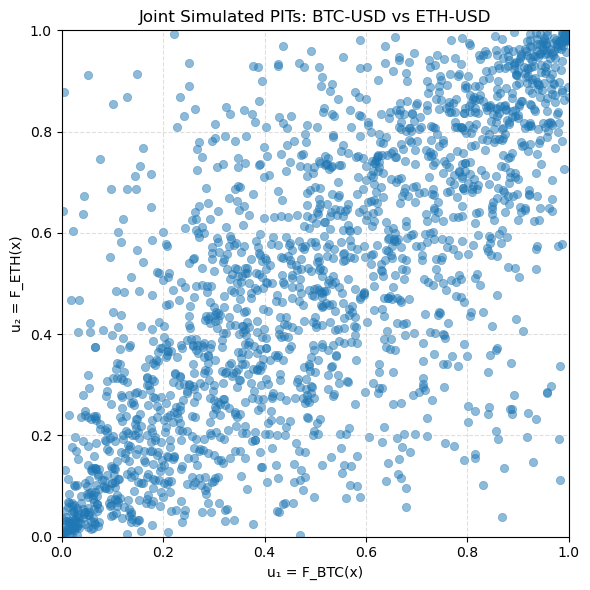

In [59]:
# Visualize joint distribution of simulated PITs
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=u_sim,
    x="BTC-USD", y="ETH-USD",
    alpha=0.5, edgecolor=None
)
plt.title("Joint Simulated PITs: BTC-USD vs ETH-USD")
plt.xlabel("u₁ = F_BTC(x)")
plt.ylabel("u₂ = F_ETH(x)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [61]:
# Save empirical tail dependence from earlier in Phase 3
tail_path = "../data/processed/joint_tail_dependence.csv"

tail_df = pd.DataFrame({
    "Tail": ["lambda_lower", "lambda_upper"],
    "Value": [lambda_lower, lambda_upper]
})

tail_df.to_csv(tail_path, index=False)
print(f"✅ Saved tail dependence values to: {tail_path}")

✅ Saved tail dependence values to: ../data/processed/joint_tail_dependence.csv


In [63]:
# Save copula model fits summary to CSV
copula_results_sorted.to_csv("../data/processed/copula_model_fits.csv", index=False)
print("✅ Saved copula model fits to: ../data/processed/copula_model_fits.csv")

✅ Saved copula model fits to: ../data/processed/copula_model_fits.csv
